# **A Data Mining Approach for Predicting Electrical Energy Consumption**


The aim of this project is  to develop a predictive model that estimates electricity
consumption based on environmental and electrical measurements also explore how weather conditions and
electrical parameters influence energy consumption and to apply machine learning techniques to
forecast electricity usage accurately.

##**1. Importing libraries and loading the dataset**.

In [ ]:
# Importing  required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV


In [ ]:
# Loading the dataset
df=pd.read_csv('/content/energy_weather_raw_data.csv')

In [ ]:
# View first 5 rows
df.head()

,date,active_power,current,voltage,reactive_power,apparent_power,power_factor,main,description,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1
0,2022-11-05 14:05:00,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
1,2022-11-05 14:06:00,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
2,2022-11-05 14:07:00,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
3,2022-11-05 14:08:00,640.0,5.45,120.7,152.08,657.82,0.9729,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
4,2022-11-05 14:09:00,257.6,2.47,122.4,158.26,302.33,0.8520,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97


##2. **Basic Understanding of data.**


In [ ]:
#Display dataset structure, data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605260 entries, 0 to 605259
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            605260 non-null  object 
 1   active_power    605260 non-null  float64
 2   current         605260 non-null  float64
 3   voltage         605260 non-null  float64
 4   reactive_power  605260 non-null  float64
 5   apparent_power  605260 non-null  float64
 6   power_factor    605260 non-null  float64
 7   main            605260 non-null  object 
 8   description     605260 non-null  object 
 9   temp            605260 non-null  float64
 10  feels_like      605260 non-null  float64
 11  temp_min        605260 non-null  float64
 12  temp_max        605260 non-null  float64
 13  pressure        605260 non-null  int64  
 14  humidity        605260 non-null  int64  
 15  speed           605260 non-null  float64
 16  deg             605260 non-null  int64  
 17  temp_t+1  

In [ ]:
#Check for missing values in all columns
print(df.isnull().sum())

date              0
active_power      0
current           0
voltage           0
reactive_power    0
apparent_power    0
power_factor      0
main              0
description       0
temp              0
feels_like        0
temp_min          0
temp_max          0
pressure          0
humidity          0
speed             0
deg               0
temp_t+1          0
feels_like_t+1    0
dtype: int64


In [ ]:
# Identify duplicate rows in the dataset
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [ ]:
#Remove duplicate records to ensure data quality
df = df.drop_duplicates()

In [ ]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [ ]:
# Summary statistics for numerical features
df.describe()

,active_power,current,voltage,reactive_power,apparent_power,power_factor,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1
count,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000,605258.000000
mean,286.019588,2.587305,125.417306,132.538099,321.839523,0.854202,19.525255,18.712624,18.086962,20.800759,1015.224674,47.954560,2.622616,152.735239,19.539571,18.728083
std,189.545945,1.591397,4.390615,71.030334,191.744207,0.114629,6.607354,6.722519,6.519216,6.351933,5.992033,19.445571,2.093098,127.593536,6.599511,6.714463
min,24.400000,0.300000,107.600000,4.730000,37.140000,0.201800,-5.560000,-6.130000,-5.560000,-5.560000,996.000000,1.000000,0.000000,0.000000,-5.560000,-6.130000
25%,159.800000,1.610000,122.600000,74.070000,203.580000,0.754600,14.810000,13.900000,13.440000,16.180000,1011.000000,32.000000,1.050000,30.000000,14.810000,13.920000
50%,250.300000,2.290000,124.400000,128.500000,286.440000,0.891700,19.490000,18.900000,18.060000,20.440000,1015.000000,47.000000,2.240000,144.000000,19.510000,18.910000
75%,365.400000,3.220000,129.500000,177.657500,401.470000,0.950000,24.250000,23.830000,22.590000,25.440000,1019.000000,63.000000,4.120000,248.000000,24.260000,23.850000
max,2900.000000,24.410000,135.500000,1293.580000,2931.640000,1.000000,39.370000,36.700000,37.590000,39.440000,1035.000000,100.000000,10.290000,360.000000,39.370000,36.700000


**Insights**

Dataset contains 605k records with no missing values and correct data types.

Only 2 duplicate rows found and removed successfully.


##3. **Basic EDA**

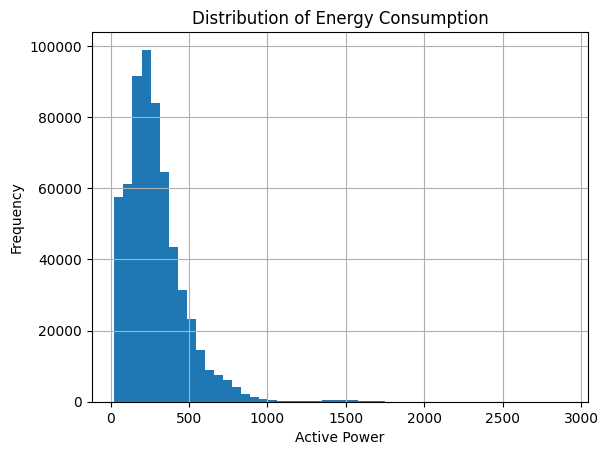

In [ ]:
# Distribution of Energy consumption
plt.figure()
df['active_power'].hist(bins=50)
plt.title('Distribution of Energy Consumption')
plt.xlabel('Active Power')
plt.ylabel('Frequency')
plt.show()

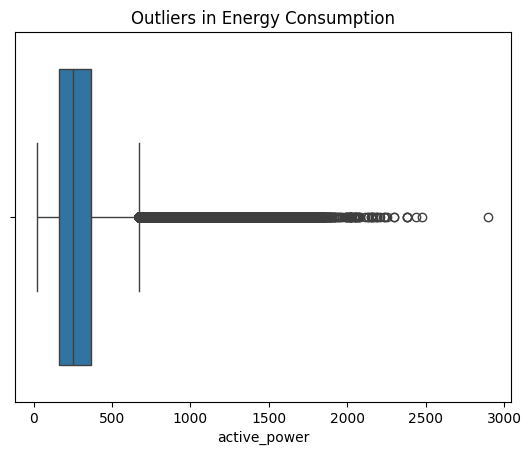

In [ ]:
# Boxplot
plt.figure()
sns.boxplot(x=df['active_power'])
plt.title('Outliers in Energy Consumption')
plt.show()

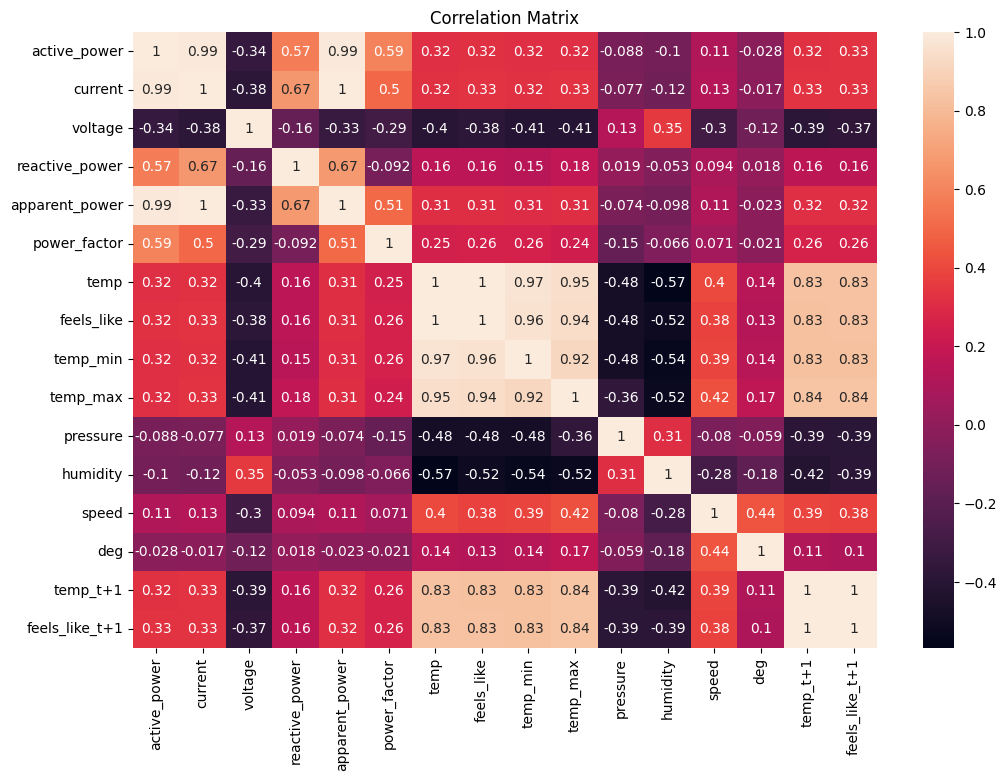

In [ ]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

**Insights**

Energy consumption distribution is right-skewed with most values at lower range.

Outliers are present with some very high energy usage values.

Strong correlation observed between energy and electrical parameters like current and apparent power.

##4.**Data Pre-processing**


In [ ]:
# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

In [ ]:
#sort data
df = df.sort_values('date')

In [ ]:
#remove column.
df = df.drop('description', axis=1)

**Insights**

Date column converted to datetime and dataset sorted in correct time order.

And removing the unnecessary column, i.e., description.

##5. **Feature Engineering**

In [ ]:
# Create time-based features from date
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

In [ ]:
# Create weekend feature
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
# View updated data
print(df.head())
print(df.info())

                 date  active_power  current  voltage  reactive_power  \
0 2022-11-05 14:05:00         265.1     2.53    122.2          159.09   
1 2022-11-05 14:06:00         265.1     2.53    122.2          159.09   
2 2022-11-05 14:07:00         265.1     2.53    122.2          159.09   
3 2022-11-05 14:08:00         640.0     5.45    120.7          152.08   
4 2022-11-05 14:09:00         257.6     2.47    122.4          158.26   

   apparent_power  power_factor   main   temp  feels_like  ...  humidity  \
0          309.17        0.8575  Clear  24.19       23.68  ...        39   
1          309.17        0.8575  Clear  24.19       23.68  ...        39   
2          309.17        0.8575  Clear  24.19       23.68  ...        39   
3          657.82        0.9729  Clear  24.19       23.68  ...        39   
4          302.33        0.8520  Clear  24.19       23.68  ...        39   

   speed  deg  temp_t+1  feels_like_t+1  hour  day  month  weekday  is_weekend  
0    0.0    0     29.63

**Insights**

Time-based features successfully created capturing daily and weekly patterns.

##6. **Advanced EDA**

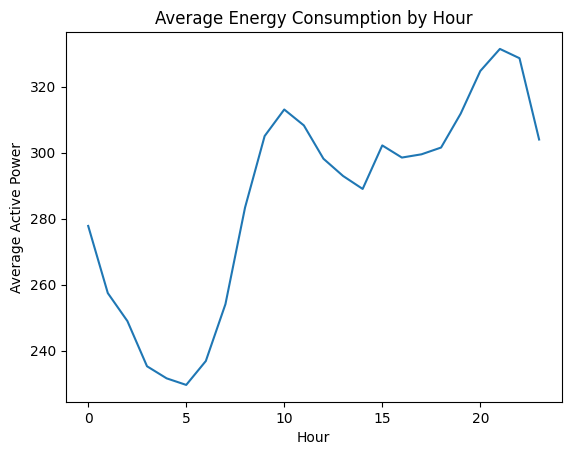

In [ ]:
# Average energy consumption by hour
hourly_avg = df.groupby('hour')['active_power'].mean()

plt.figure()
hourly_avg.plot()
plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Active Power')
plt.show()

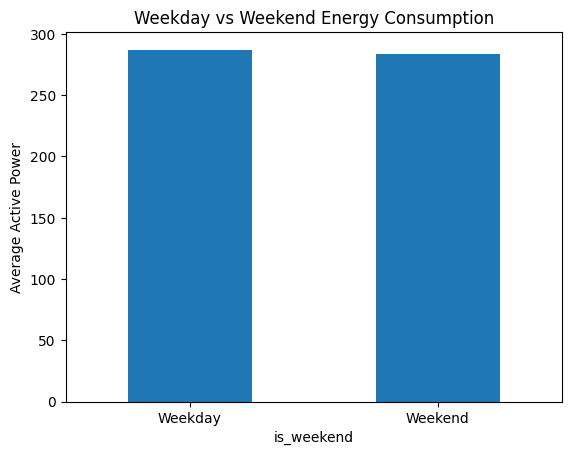

In [ ]:
# Compare weekday vs weekend
weekend_avg = df.groupby('is_weekend')['active_power'].mean()

plt.figure()
weekend_avg.plot(kind='bar')
plt.title('Weekday vs Weekend Energy Consumption')
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Active Power')
plt.show()

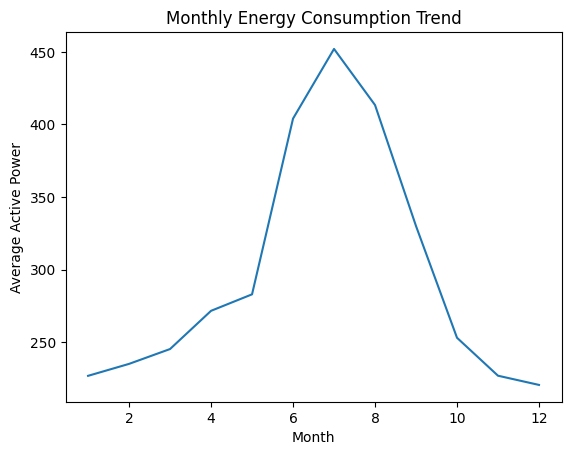

In [ ]:
# Monthly average energy
monthly_avg = df.groupby('month')['active_power'].mean()

plt.figure()
monthly_avg.plot()
plt.title('Monthly Energy Consumption Trend')
plt.xlabel('Month')
plt.ylabel('Average Active Power')
plt.show()

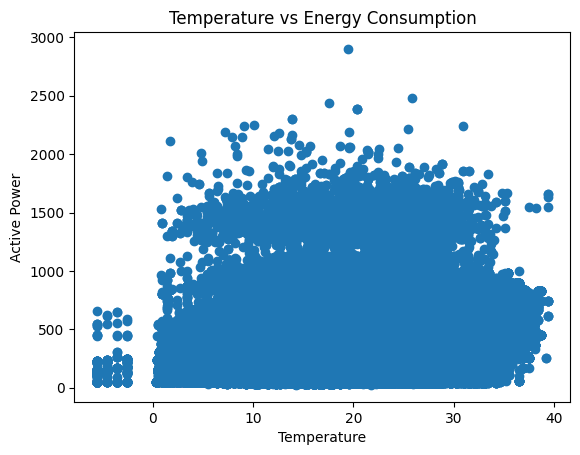

In [ ]:
# Temperature vs energy
plt.figure()
plt.scatter(df['temp'], df['active_power'])
plt.title('Temperature vs Energy Consumption')
plt.xlabel('Temperature')
plt.ylabel('Active Power')
plt.show()

**Insights**

Energy usage varies by hour with peak consumption during certain times of day.

Weekend and weekday energy consumption show noticeable differences.

Monthly trend indicates seasonal variation in energy usage.

Temperature shows a moderate relationship with energy consumption.

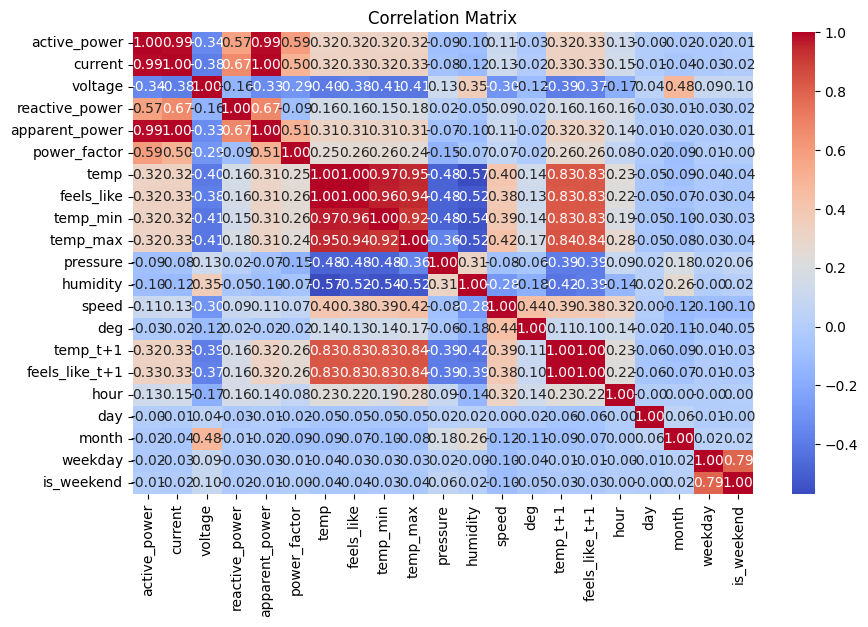

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

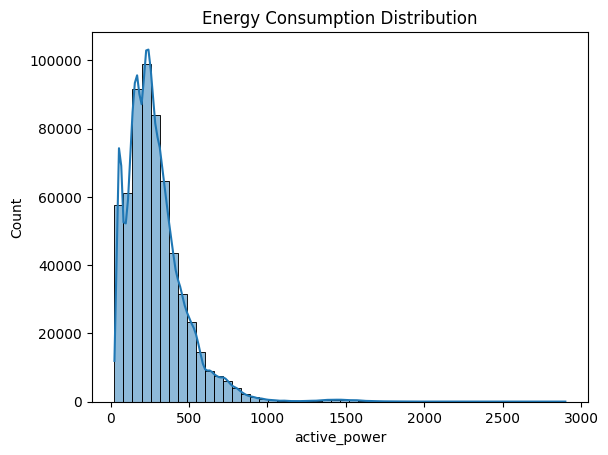

In [ ]:
plt.figure()
sns.histplot(df['active_power'], bins=50, kde=True)
plt.title('Energy Consumption Distribution')
plt.show()

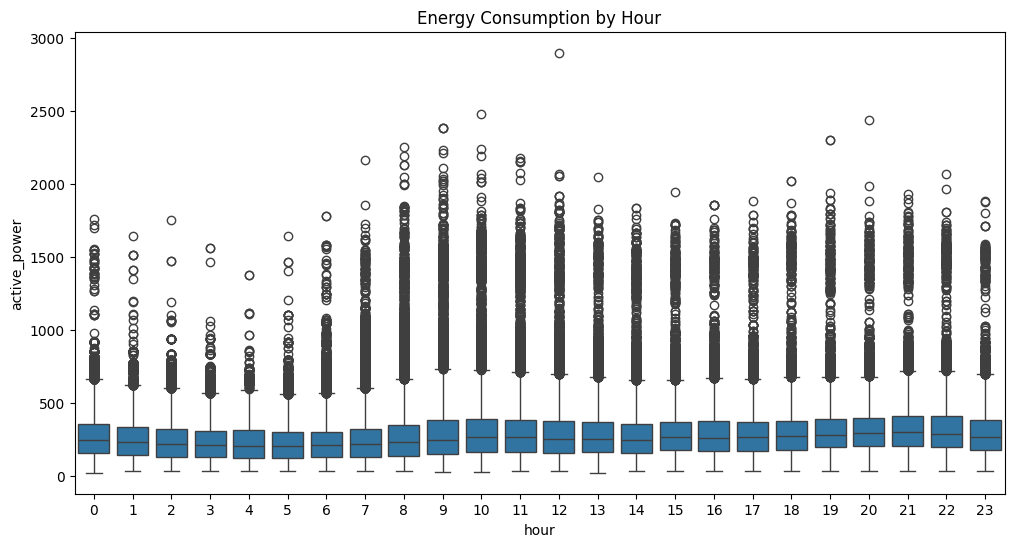

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='hour', y='active_power', data=df)
plt.title('Energy Consumption by Hour')
plt.show()

**Insights**

Correlation heatmap confirms relationships between multiple variables.

Energy distribution shows concentration at lower values with long tail.

Hourly boxplot shows variation and spread of energy consumption over time.

##7. **Feature Engineering**

In [ ]:
# Lag features
df['lag_1'] = df['active_power'].shift(1)
df['lag_2'] = df['active_power'].shift(2)
df['lag_3'] = df['active_power'].shift(3)

# Rolling features
df['rolling_mean_3'] = df['active_power'].rolling(3).mean()
df['rolling_std_3'] = df['active_power'].rolling(3).std()
df['rolling_mean_6'] = df['active_power'].rolling(6).mean()
df['rolling_std_6'] = df['active_power'].rolling(6).std()

**Insights**

Lag and rolling features successfully capture past energy trends and variability.

Lag  up to three previous shift were included to capture short term dependencies.

Rolling mean and standard deviation features with window sizes of 3 and 6  used to represent short and medium term trends.


In [ ]:
# One-hot encoding for categorical feature
df = pd.get_dummies(df, columns=['main'], drop_first=True)

**Insights**

Categorical weather data converted into numerical format and unnecessary text column removed.

In [ ]:
# Create target as next time step
df['target'] = df['active_power'].shift(-1)

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
# Features
X = df.drop(['target', 'date'], axis=1)
# Target (output)
y = df['target']
# Check selected features
print("Selected Features:\n", X.columns)
print("X shape:", X.shape)
print("y shape:", y.shape)

Selected Features:
 Index(['active_power', 'current', 'voltage', 'reactive_power',
       'apparent_power', 'power_factor', 'temp', 'feels_like', 'temp_min',
       'temp_max', 'pressure', 'humidity', 'speed', 'deg', 'temp_t+1',
       'feels_like_t+1', 'hour', 'day', 'month', 'weekday', 'is_weekend',
       'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3',
       'rolling_mean_6', 'rolling_std_6', 'main_Clouds', 'main_Drizzle',
       'main_Fog', 'main_Haze', 'main_Mist', 'main_Rain', 'main_Thunderstorm'],
      dtype='object')
X shape: (605252, 35)
y shape: (605252,)


In [ ]:
# 70% train, 30% test
train_size = int(len(df) * 0.7)

# Time-series split
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (423676, 35)
X_test shape: (181576, 35)
y_train shape: (423676,)
y_test shape: (181576,)


In [ ]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insights**

Target variable created representing next time-step energy consumption.

Final dataset contains 35 input features used for model training.

Data split into 70% training and 30% testing while preserving time sequence.

Features standardized to improve performance of scale-sensitive models like Linear Regression.


##8. **Modelling**

In [ ]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


#Decision Tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


#Random Forest
rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


#XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

**Insights**

Linear Regression and Decision Tree were trained as baseline model and Random Forest was trained for complex patterns.

##9. **Model Evaluation**

In [ ]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

# Decision Tree
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)


print("Model Performance")

print("\nLinear Regression")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2: {r2_lr:.3f}")

print("\nDecision Tree")
print(f"MAE: {mae_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R2: {r2_dt:.3f}")

print("\nRandom Forest")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2: {r2_rf:.3f}")

print("\nXGBoost")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R2: {r2_xgb:.3f}")

Model Performance

Linear Regression
MAE: 40.01
RMSE: 116.69
R2: 0.588

Decision Tree
MAE: 38.89
RMSE: 114.88
R2: 0.600

Random Forest
MAE: 41.52
RMSE: 114.45
R2: 0.603

XGBoost
MAE: 41.57
RMSE: 114.06
R2: 0.606


**Insights**

XGBoost achieved the highest R² 0.60 and lowest RMSE of 114.06.

Decision Tree has the lowest MAE 38.89 which is best for average error but less stable.

Random Forest slightly improves over Decision Tree.

Linear Regression performs worst which indicates a nonlinear relationship in the data.

##10. **Hyperparameter tuning**

In [ ]:
#CV
tscv = TimeSeriesSplit(n_splits=2)

#Random Forest search
param_dist_rf = {
    'n_estimators': [30, 100],
    'max_depth': [8, 12],
    'max_features': ['sqrt'],
    'min_samples_split': [2, 10]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=4,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_rf.fit(X_train, y_train)
print("Best Parameters for Random Forest:", random_rf.best_params_)


#XGBoost search
param_dist_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_model_random = xgb.XGBRegressor(
    random_state=42,
    n_jobs=1,
    objective='reg:squarederror',
    eval_metric='rmse'
)

random_xgb = RandomizedSearchCV(
    estimator=xgb_model_random,
    param_distributions=param_dist_xgb,
    n_iter=4,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=1,
    random_state=42
)

random_xgb.fit(X_train, y_train)
print("Best Parameters for XGBoost:", random_xgb.best_params_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best Parameters for Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 8}
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best Parameters for XGBoost: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


In [ ]:
# training the model with the best parameters
best_rf = random_rf.best_estimator_
best_xgb = random_xgb.best_estimator_

# Fit on full training data
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

# Predictions
y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)

**Insights**

Optimal Random Forest and XGBoost parameters identified using cross-validation.

In [ ]:
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned) ** 0.5
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned) ** 0.5
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("Final Model Performance")

print("\nRandom Forest (Tuned)")
print(f"MAE: {mae_rf_tuned:.2f}")
print(f"RMSE: {rmse_rf_tuned:.2f}")
print(f"R2: {r2_rf_tuned:.3f}")

print("\nXGBoost (Tuned)")
print(f"MAE: {mae_xgb_tuned:.2f}")
print(f"RMSE: {rmse_xgb_tuned:.2f}")
print(f"R2: {r2_xgb_tuned:.3f}")

print("\nDecision Tree")
print(f"MAE: {mae_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R2: {r2_dt:.3f}")

print("\nLinear Regression")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2: {r2_lr:.3f}")

Final Model Performance

Random Forest (Tuned)
MAE: 39.93
RMSE: 113.77
R2: 0.608

XGBoost (Tuned)
MAE: 41.12
RMSE: 113.88
R2: 0.607

Decision Tree
MAE: 38.89
RMSE: 114.88
R2: 0.600

Linear Regression
MAE: 40.01
RMSE: 116.69
R2: 0.588


##11. **Model Comparision**

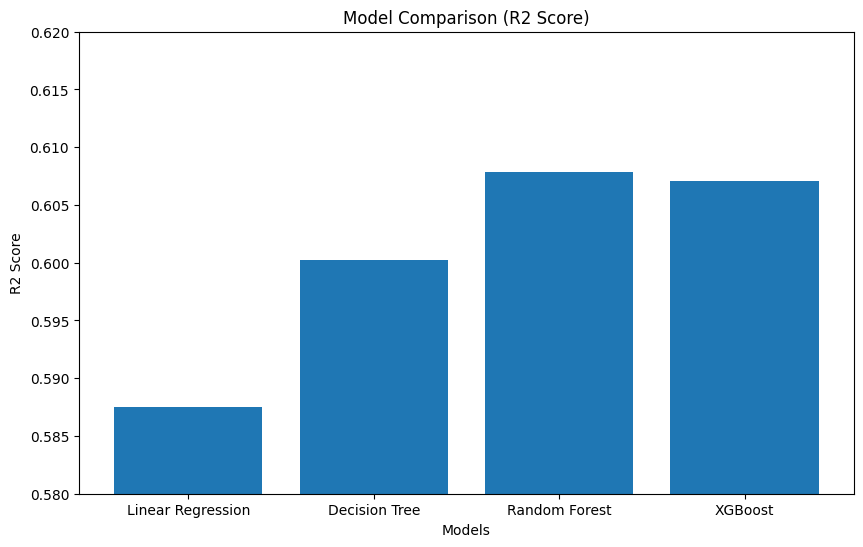

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
r2_scores = [r2_lr, r2_dt, r2_rf_tuned, r2_xgb_tuned]

plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores)

plt.title('Model Comparison (R2 Score)')
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.ylim(0.58, 0.62)

plt.show()

**Insights**

Random Forest has the highest R² i.e. 0.608 after tuning.

XGBoost is very close 0.607 after tuning as strong alternative.

Decision Tree performs better than Linear Regression.

Linear Regression has the lowest R² 0.588 known as the weakest model.

Ensemble models like RF and XGB are clearly outperform single models.

Improvement from Decision Tree to Random Forest shows benefit of ensemble learning.

R² ≈ 0.60 is the models explain about 60% of the variance.

##12. **Feature importance**

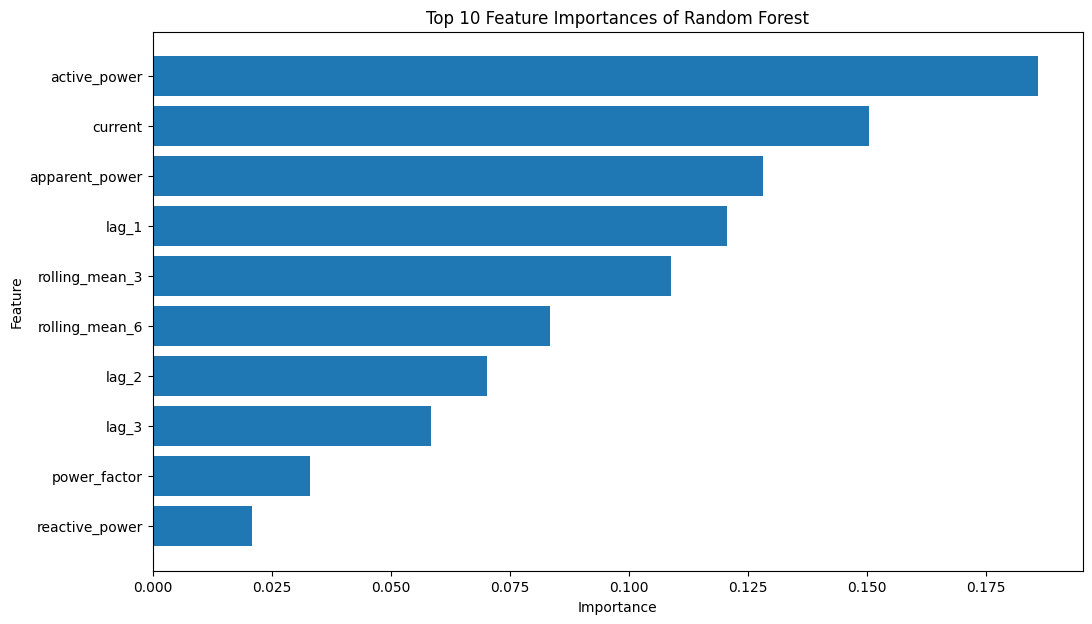

In [ ]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 7))
plt.barh(feat_imp.head(10).index[::-1], feat_imp.head(10).values[::-1])
plt.title('Top 10 Feature Importances of Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Insights**

Active power is the most important feature and use for the strongest predictor of future values.

Lag_1 and rolling features are highly important which confirms time dependency and usefulness of feature engineering.

Electrical variables like current, apparent power are significantly influence prediction.

Importance decreases for older lag_2 and lag_3, and some features like reactive power, contribute very little.

##13. **Residuals analysis**

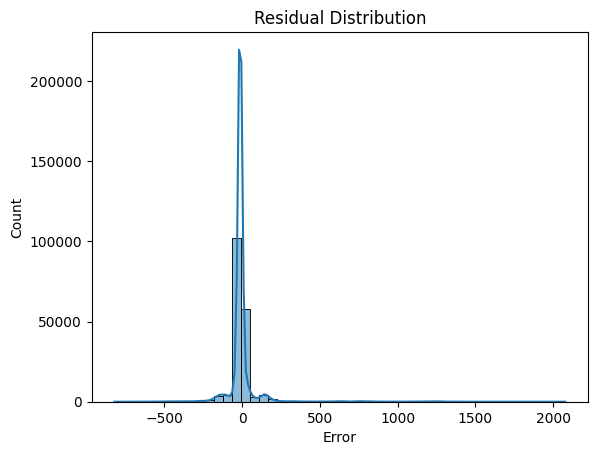

In [ ]:
# Residuals
residuals = y_test - y_pred_rf_tuned

plt.figure()
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

**Insights**

Residuals are centered around zero which indicates the model has low overall bias.

Distribution is highly peaked near zero whoch shows most predictions are accurate.

Long tailed outliers indicates that some large prediction errors exist.

Shows slight skewness where errors are not perfectly symmetric.

# ***Model successfully captures energy consumption patterns using historical and environmental features.***